# MNIST Classification (V3: Deeper ANN)

This version explores the impact of increasing model depth on performance.

The focus is not just accuracy improvement, but understanding how deeper networks affect learning and generalization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

## Load Dataset
Using the MNIST dataset of handwritten digits.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data() 


## Data Preprocessing
- Normalize pixel values to [0, 1]
- Flatten images into vectors of size 784

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

## Model Architecture

Changes from previous versions:
- Increased depth (2 hidden layers)
- Higher capacity (256 → 128 neurons)

Goal: Observe how deeper networks impact performance and overfitting.

In [4]:
model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(784,)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [5]:
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model Training

Training with controlled parameters:
- Epochs: 20
- Batch Size: 32

Note: No regularization is applied in this version (v3).

In [6]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9387 - loss: 0.2035 - val_accuracy: 0.9672 - val_loss: 0.0990
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9732 - loss: 0.0856 - val_accuracy: 0.9761 - val_loss: 0.0715
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9818 - loss: 0.0588 - val_accuracy: 0.9768 - val_loss: 0.0758
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9854 - loss: 0.0448 - val_accuracy: 0.9784 - val_loss: 0.0732
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9885 - loss: 0.0354 - val_accuracy: 0.9766 - val_loss: 0.0841
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9904 - loss: 0.0290 - val_accuracy: 0.9781 - val_loss: 0.0847
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9919 - loss: 0.0247 - val_accuracy: 0.9808 - val_loss: 0.0793
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9932 - loss: 0.0211 - 

## Accuracy Plot

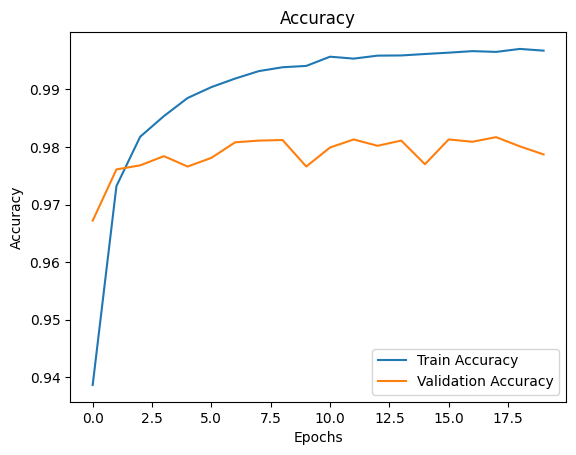

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

## Loss Plot

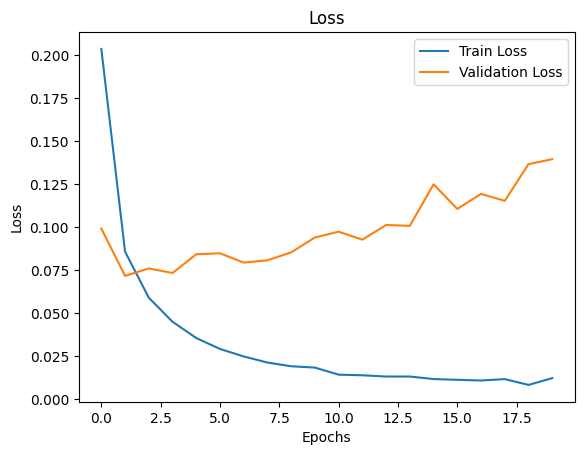

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train Loss', 'Validation Loss'])
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Model Evaluation

In [9]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.1394     


[0.13936355710029602, 0.9786999821662903]

## Key Observations

- Training accuracy exceeds 99%, indicating high model capacity
- Validation accuracy remains stable (~97–98%)
- Validation loss decreases initially but increases after early epochs

This indicates early overfitting: the model becomes increasingly confident without improving generalization.